In [13]:
import os
import json

import matplotlib.pyplot as plt
import pandas as pd


In [14]:
STAT_PATH = "C:/Users/xmelo/AppData/LocalLow/DefaultCompany/_monobeh_boinc"
CLIENTS_DYNAMIC_NAME = "clients_dynamic"
PARAMS_NAME = "parameters.json"
EXP_NAME = "statistics"


In [15]:
def read_total_clients(params_path):
    with open(params_path, "r", encoding="utf-8") as file:
        params = json.load(file)

    return int(params["GroupConfig"]["NumberOfClients"])


def read_active_clients(file_path):
    df = pd.read_csv(file_path, header=None, names=["clients_delta"])
    df["active_clients"] = df["clients_delta"].cumsum()
    df["time_hours"] = df.index / 3600.0
    return df


def plot_active_clients(ax, df, label):
    ax.plot(df["time_hours"], df["active_clients"], label=label)
    ax.set_title("Online hosts")
    ax.set_xlabel("Time, h")
    ax.set_ylabel("Active hosts")
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)


found ['statistics_1', 'statistics_2']


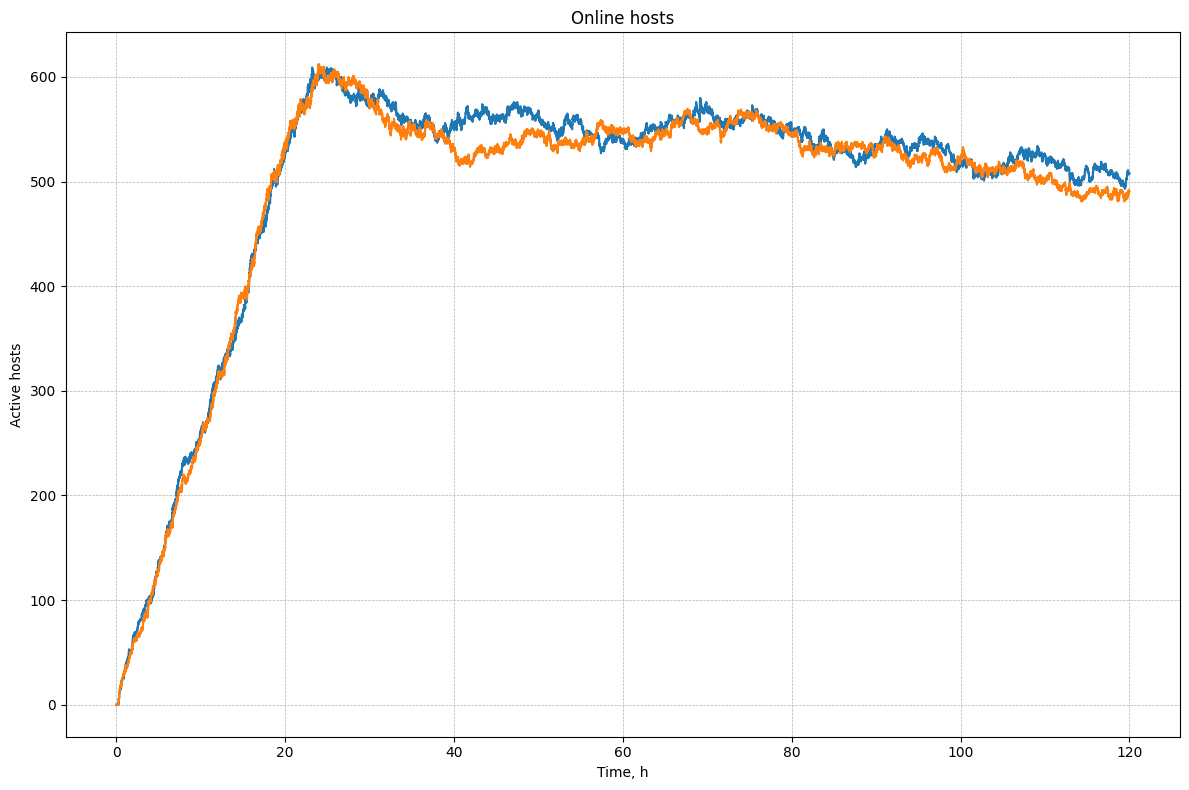

In [16]:
folders = sorted(
    folder
    for folder in os.listdir(STAT_PATH)
    if os.path.isdir(os.path.join(STAT_PATH, folder)) and folder.startswith(EXP_NAME)
)

if not folders:
    print(f"there is no folders in {STAT_PATH}")
else:
    print(f"found {folders}")

datasets = []

for folder in folders:
    full_path = os.path.join(STAT_PATH, folder)
    clients_dynamic_path = os.path.join(full_path, CLIENTS_DYNAMIC_NAME)

    if not os.path.exists(clients_dynamic_path):
        print(f"skip {folder}: {CLIENTS_DYNAMIC_NAME} not found, rerun simulation with updated boinc_simulator.c")
        continue

    total_clients = None
    params_path = os.path.join(full_path, PARAMS_NAME)
    if os.path.exists(params_path):
        total_clients = read_total_clients(params_path)

    label = folder
    if total_clients is not None:
        label = f"{folder} ({total_clients} clients)"

    datasets.append((label, read_active_clients(clients_dynamic_path)))

if not datasets:
    print("there is no active hosts data to plot")
else:
    fig, ax = plt.subplots(figsize=(12, 8))

    for label, df in datasets:
        plot_active_clients(ax, df, label)

    plt.tight_layout()
    plt.show()
